# Atera reader — exploratory analysis

Loads a sample Atera (10x Genomics next-gen in-situ) output bundle with the new
`spatialdata_io.atera` reader, then runs a standard analysis (normalization, PCA,
UMAP, clustering) and visualizes results spatially. The updates to spatialdata-io were purposefully built to encourage lazy loading of data whenever possible

## Setup: environment, code, and sample data

Run these steps **once**, in a terminal (not in this notebook), before running the cells below.

### 1. Create the conda/mamba environment

```bash
micromamba create -n spatial_data_atera -c conda-forge python=3.12 -y
micromamba activate spatial_data_atera
```

(`conda create -n spatial_data_atera python=3.12 -y && conda activate spatial_data_atera` works the same way if you use `conda` instead of `micromamba`.)

### 2. Clone the branch with the Atera reader

```bash
git clone --branch 10XGenomics:atera-reader https://github.com/scverse/spatialdata-io
cd spatialdata-io
```

### 3. Install the package and notebook dependencies

```bash
# editable install of spatialdata-io itself (pulls in scanpy, spatialdata, dask, etc.)
pip install -e .

# extra packages used only by this notebook (plotting, PCA, monitoring, GDrive download)
pip install spatialdata-plot scikit-learn psutil ipykernel "zarr>=3"
```

### 4. Register the Jupyter kernel

```bash
python -m ipykernel install --user --name spatial_data_atera --display-name "Python (spatial_data_atera)"
```

In Jupyter/VS Code, select the **"Python (spatial_data_atera)"** kernel for this notebook.

### 5. Download the tiny sample dataset

The dataset lives on the 10x Genomics support site:
https://cf.10xgenomics.com/samples/atera/1.0.0/tiny_atera_dataset/tiny_atera_dataset_outs.zip
Download it with `curl`:

```bash
mkdir -p data/tiny_atera_dataset
cd data/tiny_atera_dataset
curl -O https://cf.10xgenomics.com/samples/atera/1.0.0/tiny_atera_dataset/tiny_atera_dataset_outs.zip
unzip tiny_atera_dataset_outs.zip
tar -xzvf morphology_2d.tar.gz
tar -xzvf morphology_3d.tar.gz
```

This creates a local folder containing the output bundle.

### 6. Point the notebook at the downloaded data

In the "Load data" cell below, set:

```python
BUNDLE_PATH = "data/tiny_atera_dataset"
```

(Check with `ls -R data/tiny_atera_dataset` — it should contain the `output_bundle`-style
contents, e.g. `cell_feature_matrix.zarr.zip`, morphology images, etc. Adjust `BUNDLE_PATH` to
point directly at the folder that contains those files.)


In [38]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import scanpy as sc
from spatialdata import bounding_box_query

from spatialdata_io import atera
import spatialdata_plot  # noqa: F401
from spatialdata_io.readers.atera import read_transcripts_for_genes
from spatialdata_io.readers.atera import read_table_for_genes

import numpy as np
from scipy.sparse import diags
import numpy as np
import pandas as pd
from scipy.sparse import issparse
from sklearn.decomposition import IncrementalPCA

%matplotlib inline

## Load data


In [39]:
sdata = atera(
    BUNDLE_PATH,
    cells_table=True,
    cells_boundaries=True,
    nucleus_boundaries=False,
    cells_labels=False,
    nucleus_labels=False,
    transcripts=True,
    morphology_images=True,
    morphology_3d_images=False,
)
sdata

/Users/stephen.williams/micromamba/envs/spatialdata-test/lib/python3.14/functools.py:1069: UserWarning: The index of the dataframe is not monotonic increasing. It is recommended to sort the data to adjust the order of the index before calling .parse() (or call `parse(sort=True)`) to avoid possible problems due to unknown divisions.
  return self._dispatch(args[0].__class__).__get__(self._obj, self._cls)(*args, **kwargs)


SpatialData object
├── Images
│     └── 'morphology': DataTree[cyx] (4, 151, 151), (4, 75, 75), (4, 37, 37), (4, 18, 18), (4, 9, 9)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 7) (3D points)
├── Shapes
│     └── 'cell_boundaries': GeoDataFrame shape: (13, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (13, 132)
with coordinate systems:
    ▸ 'global', with elements:
        morphology (Images), transcripts (Points), cell_boundaries (Shapes)

# Check the data structures

In [40]:
sdata.images

{'morphology': <xarray.DataTree>
Group: /
├── Group: /scale0
│       Dimensions:  (c: 4, y: 151, x: 151)
│       Coordinates:
│         * c        (c) <U22 352B 'DAPI' ... 'alphaSMA/Vimentin'
│         * y        (y) float64 1kB 0.5 1.5 2.5 3.5 4.5 ... 147.5 148.5 149.5 150.5
│         * x        (x) float64 1kB 0.5 1.5 2.5 3.5 4.5 ... 147.5 148.5 149.5 150.5
│       Data variables:
│           image    (c, y, x) uint16 182kB dask.array<chunksize=(1, 151, 151), meta=np.ndarray>
├── Group: /scale1
│       Dimensions:  (c: 4, y: 75, x: 75)
│       Coordinates:
│         * c        (c) <U22 352B 'DAPI' ... 'alphaSMA/Vimentin'
│         * y        (y) float64 600B 1.007 3.02 5.033 7.047 ... 144.0 146.0 148.0 150.0
│         * x        (x) float64 600B 1.007 3.02 5.033 7.047 ... 144.0 146.0 148.0 150.0
│       Data variables:
│           image    (c, y, x) uint16 45kB dask.array<chunksize=(1, 75, 75), meta=np.ndarray>
├── Group: /scale2
│       Dimensions:  (c: 4, y: 37, x: 37)
│       Coor

In [41]:
sdata.images['morphology'].to_dict()

{'/': <xarray.Dataset> Size: 0B
 Dimensions:  ()
 Data variables:
     *empty*,
 '/scale0': <xarray.Dataset> Size: 185kB
 Dimensions:  (c: 4, y: 151, x: 151)
 Coordinates:
   * c        (c) <U22 352B 'DAPI' ... 'alphaSMA/Vimentin'
   * y        (y) float64 1kB 0.5 1.5 2.5 3.5 4.5 ... 147.5 148.5 149.5 150.5
   * x        (x) float64 1kB 0.5 1.5 2.5 3.5 4.5 ... 147.5 148.5 149.5 150.5
 Data variables:
     image    (c, y, x) uint16 182kB dask.array<chunksize=(1, 151, 151), meta=np.ndarray>,
 '/scale1': <xarray.Dataset> Size: 47kB
 Dimensions:  (c: 4, y: 75, x: 75)
 Coordinates:
   * c        (c) <U22 352B 'DAPI' ... 'alphaSMA/Vimentin'
   * y        (y) float64 600B 1.007 3.02 5.033 7.047 ... 144.0 146.0 148.0 150.0
   * x        (x) float64 600B 1.007 3.02 5.033 7.047 ... 144.0 146.0 148.0 150.0
 Data variables:
     image    (c, y, x) uint16 45kB dask.array<chunksize=(1, 75, 75), meta=np.ndarray>,
 '/scale2': <xarray.Dataset> Size: 12kB
 Dimensions:  (c: 4, y: 37, x: 37)
 Coordinates:

In [42]:
sdata.tables["table"].var

,feature_name,filtered,highly_variable,feature_id,feature_type,genome
feature_id,,,,,,
ENSG00000177556,ATOX1,True,True,ENSG00000177556,Gene Expression,hg38
ENSG00000205502,C2CD4B,True,True,ENSG00000205502,Gene Expression,hg38
ENSG00000177455,CD19,True,True,ENSG00000177455,Gene Expression,hg38
ENSG00000186407,CD300E,False,False,ENSG00000186407,Gene Expression,hg38
ENSG00000161649,CD300LG,True,True,ENSG00000161649,Gene Expression,hg38
...,...,...,...,...,...,...
UnassignedCodeword_0019,UnassignedCodeword_0019,False,False,UnassignedCodeword_0019,Unassigned Codeword,Unassigned Codeword
UnassignedCodeword_0023,UnassignedCodeword_0023,False,False,UnassignedCodeword_0023,Unassigned Codeword,Unassigned Codeword
UnassignedCodeword_0081,UnassignedCodeword_0081,False,False,UnassignedCodeword_0081,Unassigned Codeword,Unassigned Codeword


In [43]:
sdata.tables["table"].obs

,barcode,cell_id,filtered,leiden_res_1.0,centroid_column,centroid_row,cell_area,nucleus_area,transcript_counts,control_probe_counts,control_codeword_counts,total_counts,azimuth_broad,azimuth_coarse,azimuth_fine,azimuth_score,azimuth_full_hierarchy,region
barcode,,,,,,,,,,,,,,,,,,
abibnbbc-1,abibnbbc-1,4320252178,True,1,16.316103,8.434508,26.766546,4.985044,55,0,0,55,Immune cell,Coarse Not Confidently Annotated,Fine Not Confidently Annotated,0.520917,Inconsistent Annotation,cell_boundaries
cijfnjdd-1,cijfnjdd-1,4975876403,True,0,6.874815,19.028240,28.697689,4.940134,53,0,0,53,Immune cell,Coarse Not Confidently Annotated,Fine Not Confidently Annotated,0.428365,Inconsistent Annotation,cell_boundaries
claeglfj-1,claeglfj-1,5016677209,True,1,26.484306,16.199251,16.526995,4.625762,30,0,0,30,Unassigned,Unassigned,Unassigned,0.612201,Unassigned,cell_boundaries
dgpljcmo-1,dgpljcmo-1,5217424078,True,0,27.408440,3.344936,32.110874,6.152713,100,1,0,101,Unassigned,Coarse Not Confidently Annotated,Fine Not Confidently Annotated,0.494260,Inconsistent Annotation,cell_boundaries
dopoijpl-1,dopoijpl-1,5351836155,True,0,18.310593,26.223713,24.565941,5.928161,70,0,0,70,Unassigned,Unassigned,Unassigned,0.910164,Unassigned,cell_boundaries
elcplmnf-1,elcplmnf-1,5556387029,True,1,24.609272,22.412422,31.257576,5.209596,52,0,0,52,Immune cell,Coarse Not Confidently Annotated,Fine Not Confidently Annotated,0.389394,Inconsistent Annotation,cell_boundaries
fheoaeid-1,fheoaeid-1,5759698051,True,0,22.915049,10.127147,21.871323,5.254507,66,0,0,66,Immune cell,Coarse Not Confidently Annotated,Fine Not Confidently Annotated,0.514863,Inconsistent Annotation,cell_boundaries
iodamdll-1,iodamdll-1,6680527803,True,0,14.134247,3.543545,8.937152,5.389237,36,0,0,36,Unassigned,Unassigned,Unassigned,0.899125,Unassigned,cell_boundaries
jabhbfdn-1,jabhbfdn-1,6712399165,True,1,16.793663,18.895208,9.161703,5.703609,26,1,0,27,Immune cell,T cell,abT (entry) cell,0.409324,Immune cell|Lymphoid cell|T/NK cell|T cell|abT...,cell_boundaries


# Plotting some QC Images

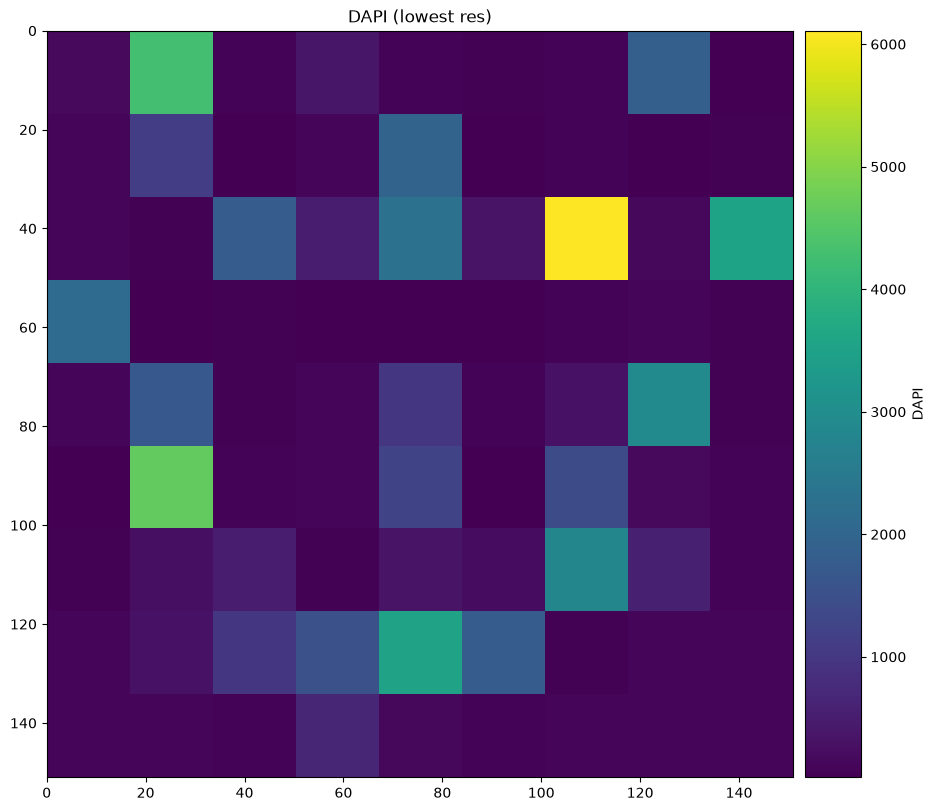

In [44]:
sdata.pl.render_images("morphology", channel="DAPI", scale="scale4").pl.show(
    title="DAPI (lowest res)", coordinate_systems="global", figsize=(8, 8)
)

## Plot cells filled by total transcript counts per cell

`transcript_counts` is a QC column already present in `obs` (no need to load the full
transcripts table for this).

In [45]:
sdata.tables["table"].obs

,barcode,cell_id,filtered,leiden_res_1.0,centroid_column,centroid_row,cell_area,nucleus_area,transcript_counts,control_probe_counts,control_codeword_counts,total_counts,azimuth_broad,azimuth_coarse,azimuth_fine,azimuth_score,azimuth_full_hierarchy,region
barcode,,,,,,,,,,,,,,,,,,
abibnbbc-1,abibnbbc-1,4320252178,True,1,16.316103,8.434508,26.766546,4.985044,55,0,0,55,Immune cell,Coarse Not Confidently Annotated,Fine Not Confidently Annotated,0.520917,Inconsistent Annotation,cell_boundaries
cijfnjdd-1,cijfnjdd-1,4975876403,True,0,6.874815,19.028240,28.697689,4.940134,53,0,0,53,Immune cell,Coarse Not Confidently Annotated,Fine Not Confidently Annotated,0.428365,Inconsistent Annotation,cell_boundaries
claeglfj-1,claeglfj-1,5016677209,True,1,26.484306,16.199251,16.526995,4.625762,30,0,0,30,Unassigned,Unassigned,Unassigned,0.612201,Unassigned,cell_boundaries
dgpljcmo-1,dgpljcmo-1,5217424078,True,0,27.408440,3.344936,32.110874,6.152713,100,1,0,101,Unassigned,Coarse Not Confidently Annotated,Fine Not Confidently Annotated,0.494260,Inconsistent Annotation,cell_boundaries
dopoijpl-1,dopoijpl-1,5351836155,True,0,18.310593,26.223713,24.565941,5.928161,70,0,0,70,Unassigned,Unassigned,Unassigned,0.910164,Unassigned,cell_boundaries
elcplmnf-1,elcplmnf-1,5556387029,True,1,24.609272,22.412422,31.257576,5.209596,52,0,0,52,Immune cell,Coarse Not Confidently Annotated,Fine Not Confidently Annotated,0.389394,Inconsistent Annotation,cell_boundaries
fheoaeid-1,fheoaeid-1,5759698051,True,0,22.915049,10.127147,21.871323,5.254507,66,0,0,66,Immune cell,Coarse Not Confidently Annotated,Fine Not Confidently Annotated,0.514863,Inconsistent Annotation,cell_boundaries
iodamdll-1,iodamdll-1,6680527803,True,0,14.134247,3.543545,8.937152,5.389237,36,0,0,36,Unassigned,Unassigned,Unassigned,0.899125,Unassigned,cell_boundaries
jabhbfdn-1,jabhbfdn-1,6712399165,True,1,16.793663,18.895208,9.161703,5.703609,26,1,0,27,Immune cell,T cell,abT (entry) cell,0.409324,Immune cell|Lymphoid cell|T/NK cell|T cell|abT...,cell_boundaries


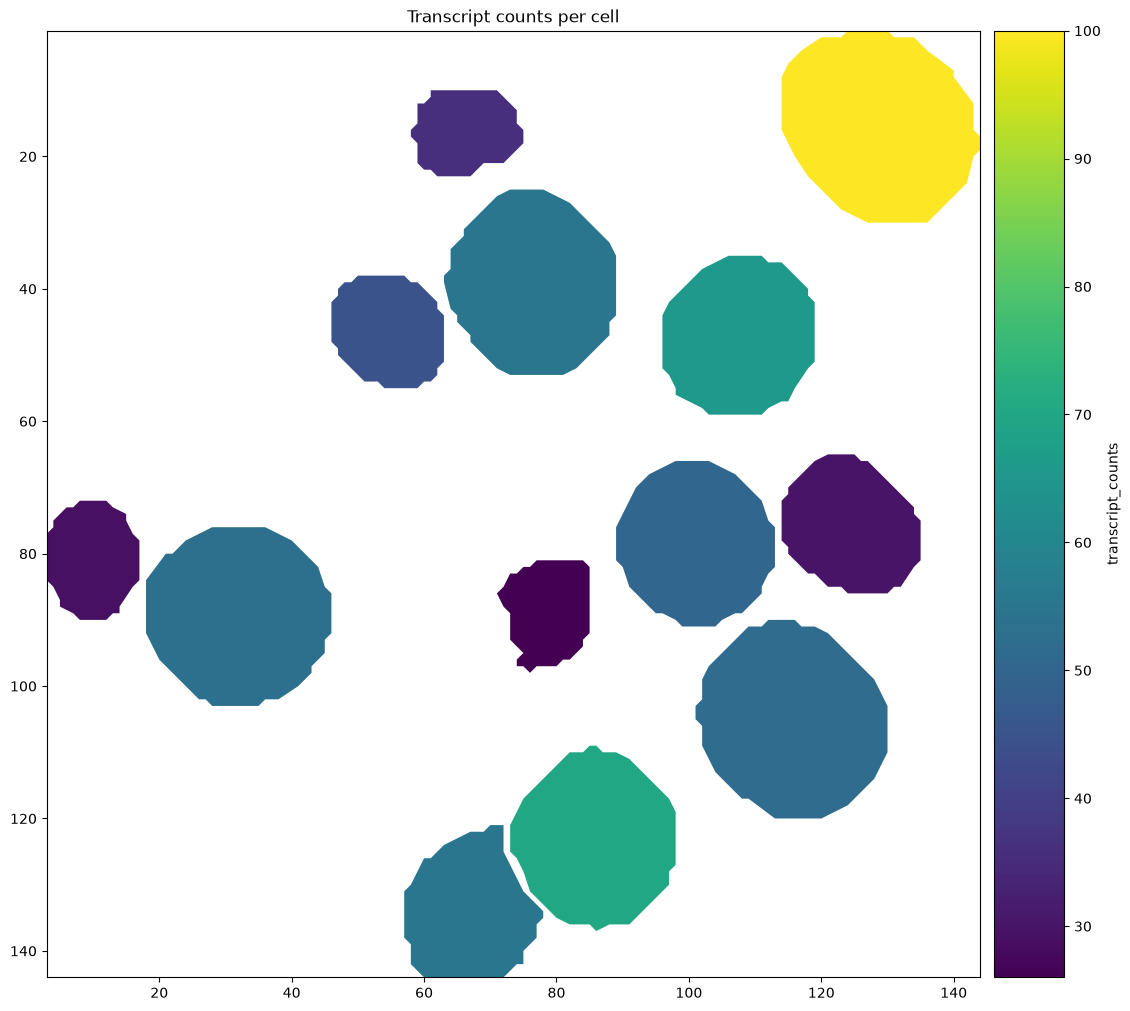

In [46]:
sdata.pl.render_shapes("cell_boundaries", color="transcript_counts", fill_alpha=1, outline_alpha=0).pl.show(
    title="Transcript counts per cell", coordinate_systems="global", figsize=(10, 10)
)


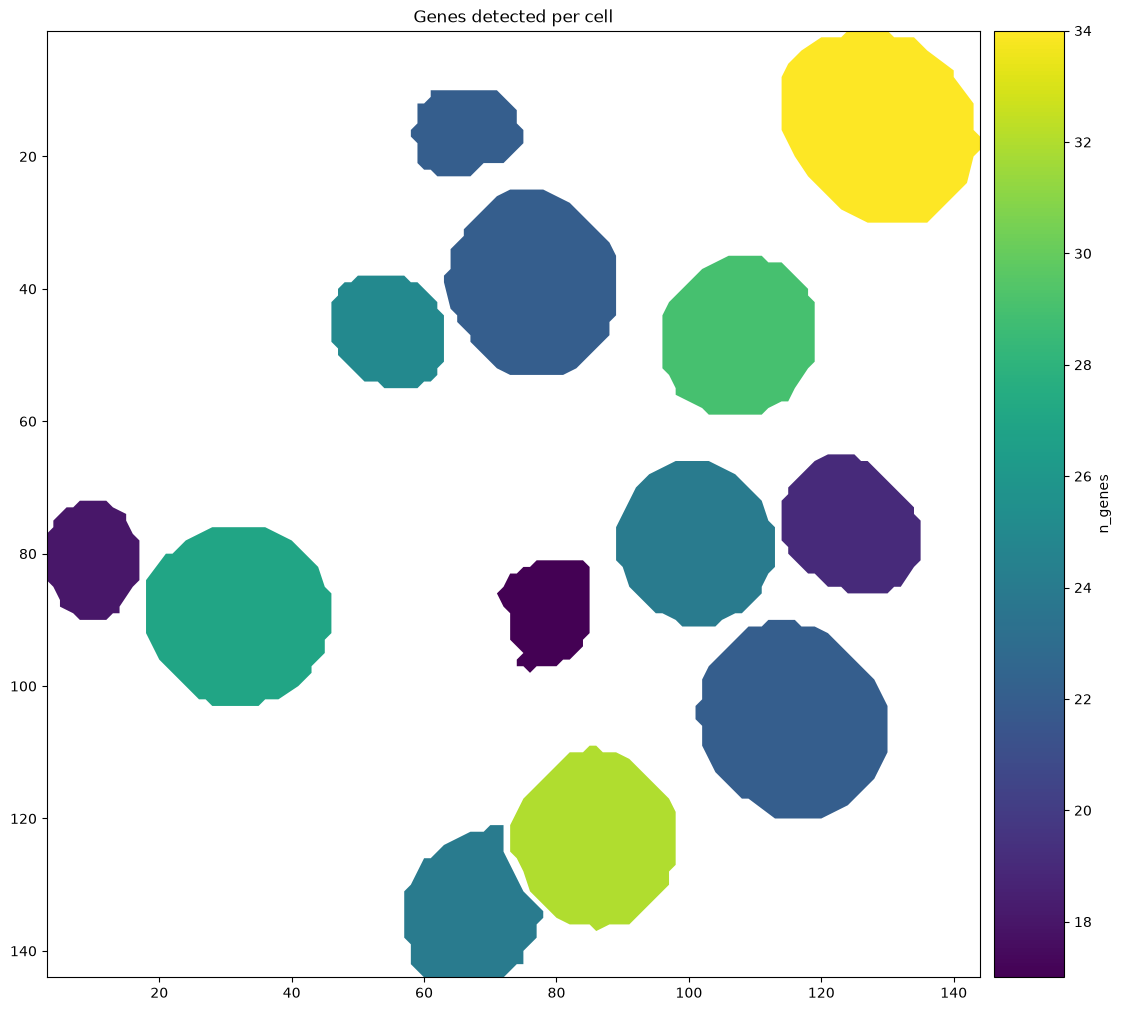

In [47]:
adata = sdata.tables["table"]
counts = adata.layers["counts"] if "counts" in adata.layers else adata.X
boolean_counts = counts > 0

n_genes_list = []
for i in range(boolean_counts.numblocks[0]):
    block = boolean_counts.blocks[i].compute()
    n_genes_list.append(np.asarray(block.sum(axis=1)).ravel())

sdata.tables["table"].obs["n_genes"] = np.concatenate(n_genes_list)

sdata.pl.render_shapes("cell_boundaries", color="n_genes", fill_alpha=1, outline_alpha=0).pl.show(
    title="Genes detected per cell", coordinate_systems="global", figsize=(10, 10)
)


## Plot transcripts spatial distribution for a single gene or multiple genes

In [48]:
sdata.tables["table"].var

,feature_name,filtered,highly_variable,feature_id,feature_type,genome
feature_id,,,,,,
ENSG00000177556,ATOX1,True,True,ENSG00000177556,Gene Expression,hg38
ENSG00000205502,C2CD4B,True,True,ENSG00000205502,Gene Expression,hg38
ENSG00000177455,CD19,True,True,ENSG00000177455,Gene Expression,hg38
ENSG00000186407,CD300E,False,False,ENSG00000186407,Gene Expression,hg38
ENSG00000161649,CD300LG,True,True,ENSG00000161649,Gene Expression,hg38
...,...,...,...,...,...,...
UnassignedCodeword_0019,UnassignedCodeword_0019,False,False,UnassignedCodeword_0019,Unassigned Codeword,Unassigned Codeword
UnassignedCodeword_0023,UnassignedCodeword_0023,False,False,UnassignedCodeword_0023,Unassigned Codeword,Unassigned Codeword
UnassignedCodeword_0081,UnassignedCodeword_0081,False,False,UnassignedCodeword_0081,Unassigned Codeword,Unassigned Codeword


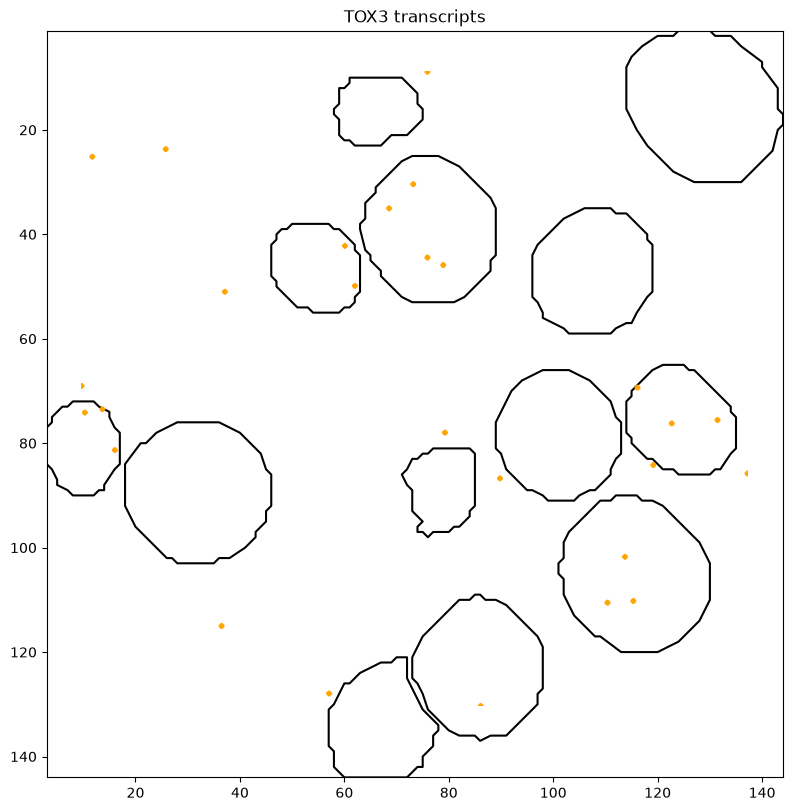

In [49]:
gene_name = "TOX3"

sdata = read_transcripts_for_genes(sdata, BUNDLE_PATH, gene_name, points_key=f"transcripts_{gene_name}")

sdata.pl.render_shapes(
    "cell_boundaries", fill_alpha=0, outline_alpha=1
).pl.render_points(
    f"transcripts_{gene_name}",
    color="orange",
    size=10, # for a real sample you want to use something more like 0.3
    method="datashader"
).pl.show(
    title=f"{gene_name} transcripts", figsize=(8, 8)
)



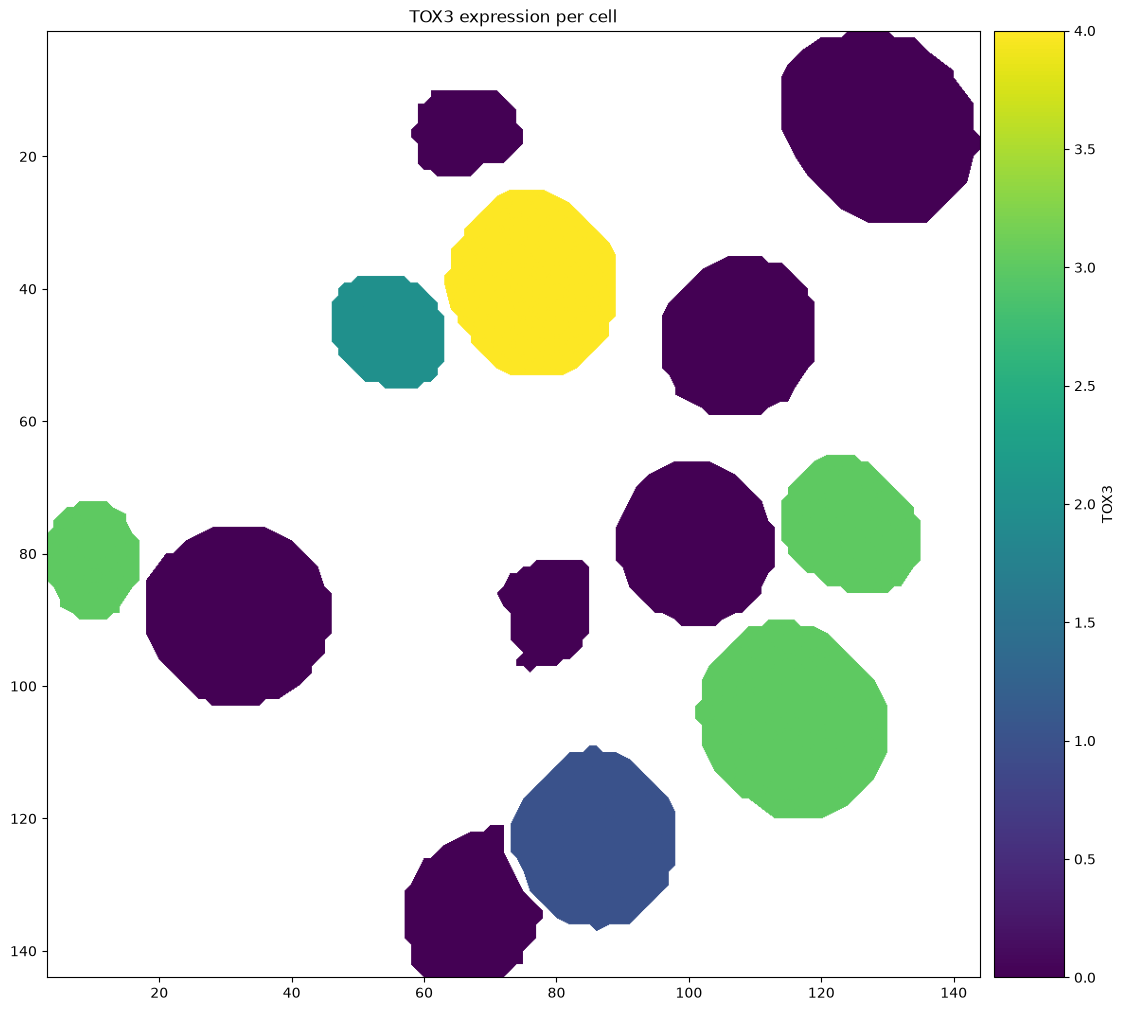

In [50]:
gene_name = "TOX3"

gene_adata = read_table_for_genes(BUNDLE_PATH, gene_name)
sdata.shapes["cell_boundaries"][gene_name] = np.asarray(gene_adata[:, gene_name].X.todense()).ravel()

sdata.pl.render_shapes(
    "cell_boundaries",
    color=gene_name,
    fill_alpha=1,
    outline_alpha=0,
    method="datashader"
).pl.show(
    title=f"{gene_name} expression per cell",
    coordinate_systems="global",
    figsize=(10, 10)
)

### Crop to a specific region.
Need spatialdata_plot >= 0.4.0

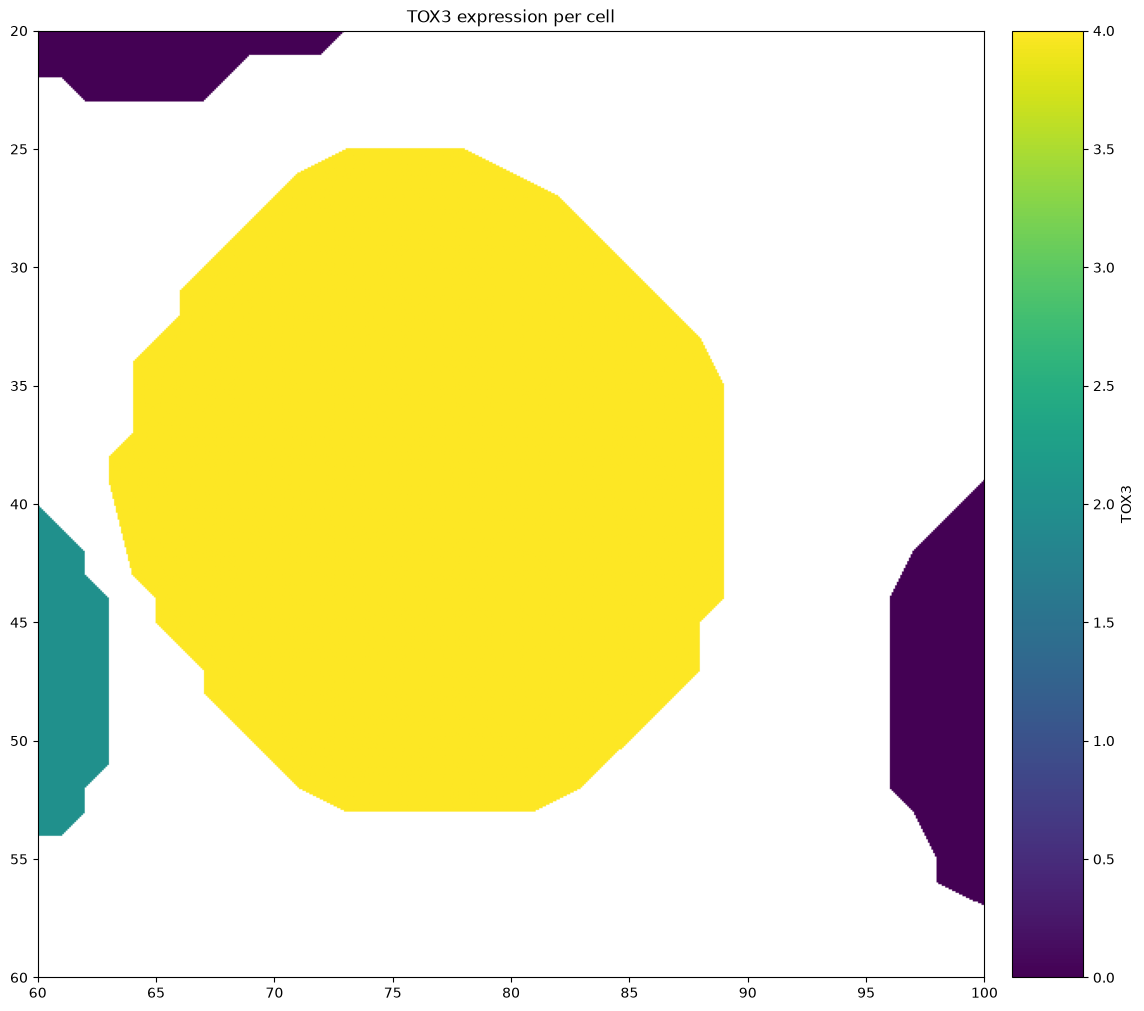

In [51]:
gene_name = "TOX3"

gene_adata = read_table_for_genes(BUNDLE_PATH, gene_name)
sdata.shapes["cell_boundaries"][gene_name] = np.asarray(gene_adata[:, gene_name].X.todense()).ravel()

sdata.pl.render_shapes(
    "cell_boundaries",
    color=gene_name,
    fill_alpha=1,
    outline_alpha=0,
    method="datashader"
).pl.show(
    title=f"{gene_name} expression per cell",
    coordinate_systems="global",
    figsize=(10, 10),
    crop_coord=(60, 100, 20, 60)

)

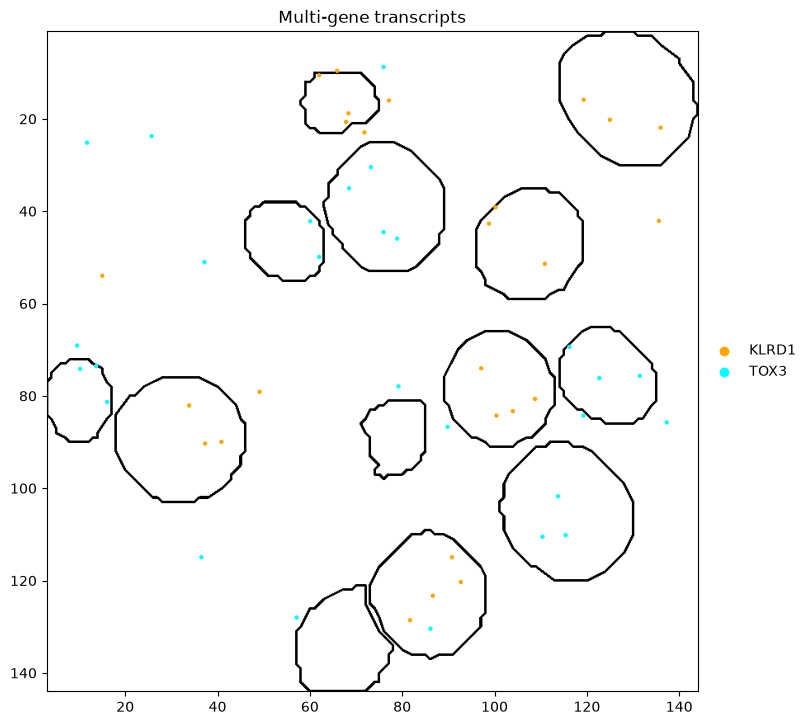

In [52]:
genes = ["KLRD1", "TOX3"]

sdata = read_transcripts_for_genes(sdata, BUNDLE_PATH, genes, points_key="transcripts_multi")

sdata.pl.render_shapes(
    "cell_boundaries", fill_alpha=0, outline_alpha=1, method="datashader"
).pl.render_points(
    "transcripts_multi",
    color="feature_name",
    groups=genes,
    palette=["orange", "cyan"],
    size=10,
).pl.show(title="Multi-gene transcripts", figsize=(8, 8))


## Plot the codewords for a gene

### All on one plot

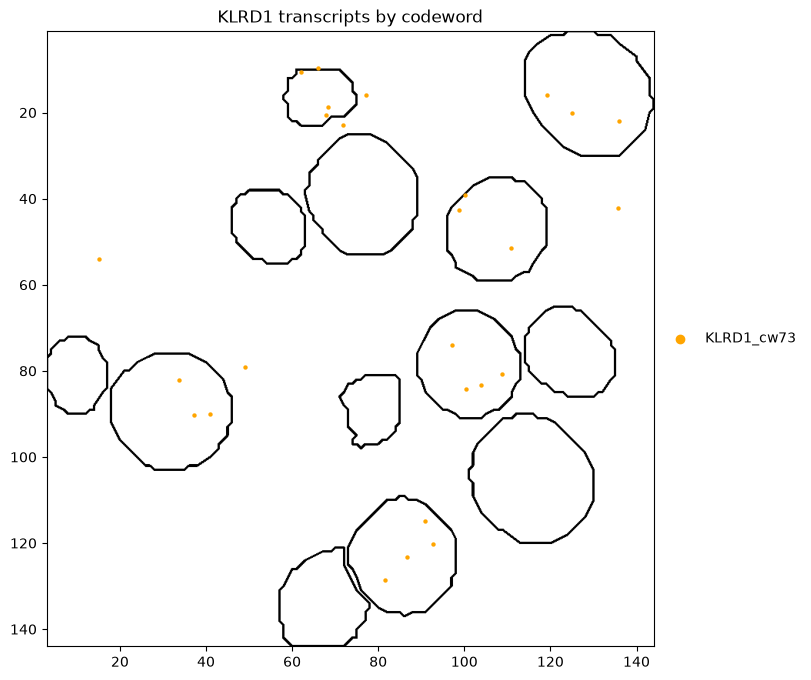

In [53]:
gene_name = "KLRD1"
sdata = read_transcripts_for_genes(
    sdata, BUNDLE_PATH, gene_name, points_key=f"transcripts_{gene_name}_codewords", by_codeword=True
)

codewords = sorted(sdata.points[f"transcripts_{gene_name}_codewords"]["feature_name"].compute().cat.categories)

sdata.pl.render_shapes(
    "cell_boundaries", fill_alpha=0, outline_alpha=1, method="datashader"
).pl.render_points(
    f"transcripts_{gene_name}_codewords",
    color="feature_name",
    groups=codewords,
    palette=["orange", "cyan", "magenta"][: len(codewords)],
    size=10,
).pl.show(title=f"{gene_name} transcripts by codeword", figsize=(8, 8))


### Codewords on multiple plots
**Wont work for this tiny dataset because there's only 1 codeword**

In [ ]:
gene_name = "TOX3"
points_key = f"transcripts_{gene_name}_codewords"

sdata = read_transcripts_for_genes(sdata, BUNDLE_PATH, gene_name, points_key=points_key, by_codeword=True)

df = sdata.points[points_key].compute()
counts = df["feature_name"].value_counts()
codewords = sorted(df["feature_name"].cat.categories)

fig, axes = plt.subplots(1, len(codewords), figsize=(6 * len(codewords), 6))
for ax, cw in zip(axes, codewords, strict=True):
    sdata.pl.render_shapes(
        "cell_boundaries", fill_alpha=0, outline_alpha=1, method="datashader"
    ).pl.render_points(
        points_key,
        color="feature_name",
        groups=cw,
        palette="orange",
        size=2,
    ).pl.show(title=f"{cw} (n={counts.get(cw, 0)})", ax=ax)

fig.tight_layout()



## Spatial plots of the cells

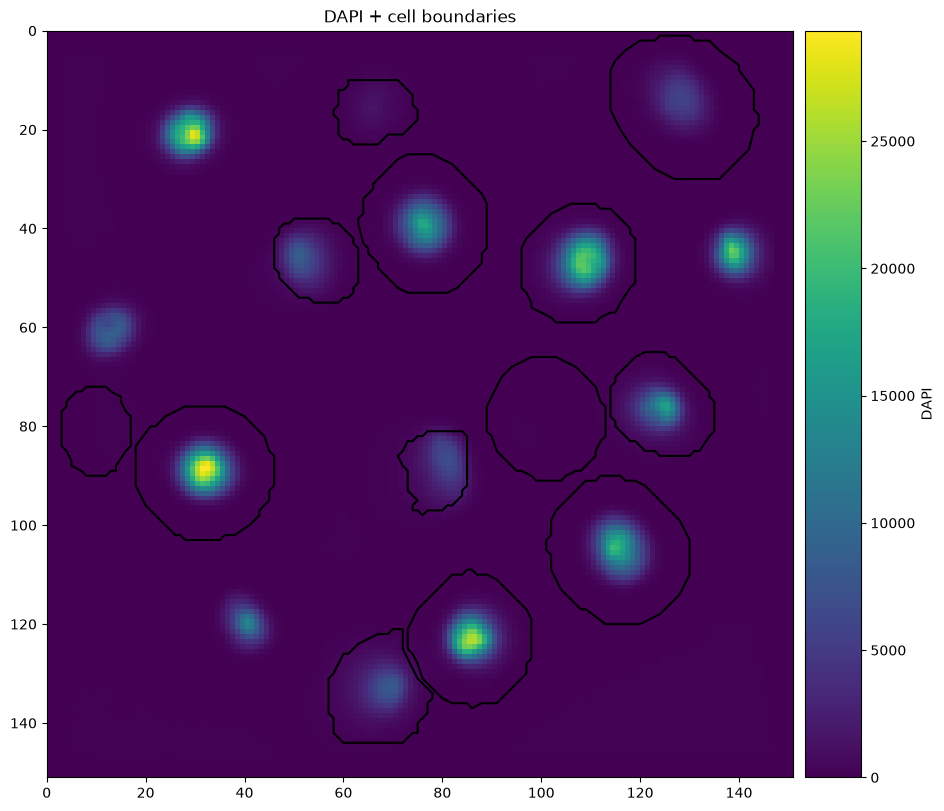

In [55]:
sdata.pl.render_images("morphology", channel="DAPI").pl.render_shapes(
    "cell_boundaries", fill_alpha=0, outline_alpha=1
).pl.show(title="DAPI + cell boundaries", coordinate_systems="global", figsize=(8, 8))

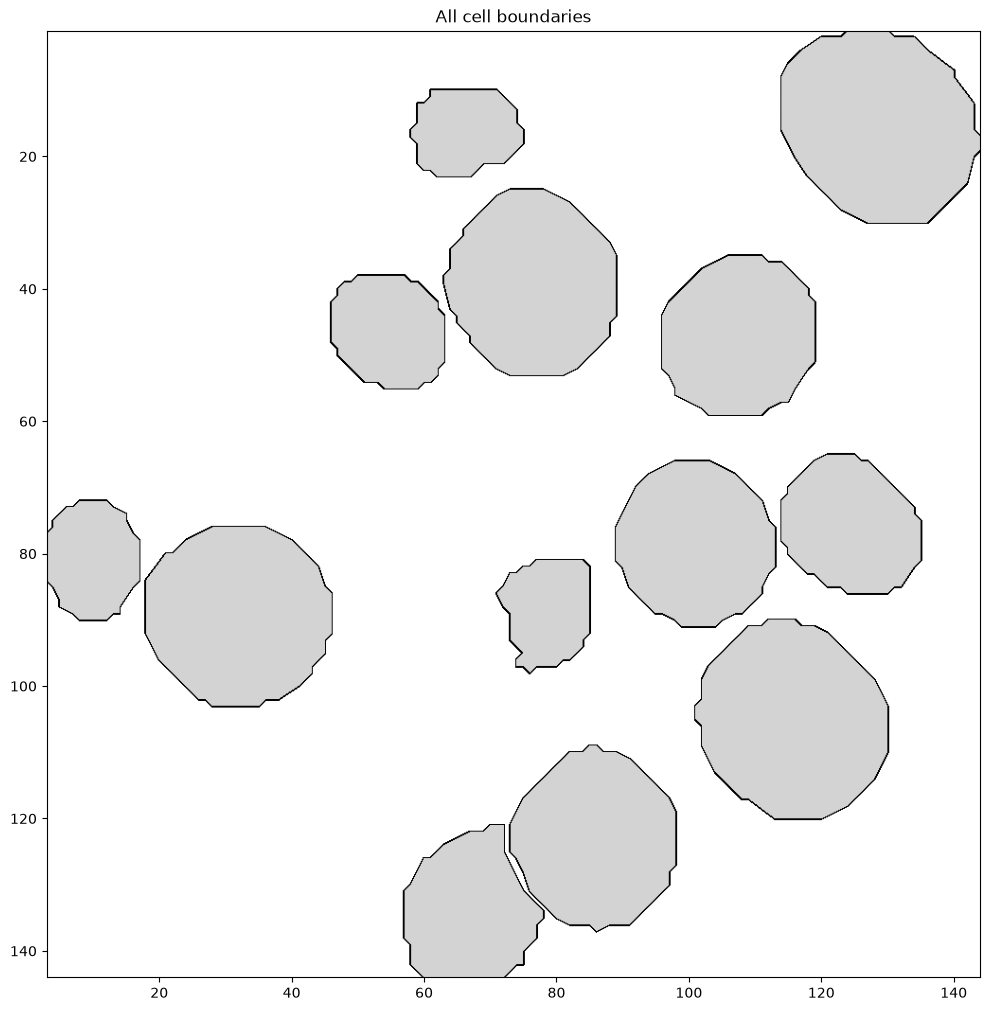

In [56]:
sdata.pl.render_shapes("cell_boundaries",  outline_alpha=1, method="datashader").pl.show(
    title="All cell boundaries", coordinate_systems="global", figsize=(10, 10)
)

## Normalization, PCA, UMAP, clustering

Standard scanpy pipeline on the cell-by-gene table.

You can see that the matrix is purposefully stored as a dask array

In [57]:
sdata.tables["table"].X

dask.array<from-value, shape=(13, 132), dtype=int32, chunksize=(13, 132), chunktype=scipy.csr_matrix>

# Normalization and HVG Detection
In testing scanpy HVG gene detection blew up the memory on the full-gene table.
So we implement a streaming mean/variance calculation that only ever holds one chunk in memory at a time.
This is also faster than scanpy's HVG, which computes the gram matrix and then does an SVD on it.

In [58]:
adata = sdata.tables["table"]
adata.layers["counts"] = adata.X.copy()  # cheap: just copies the dask graph

sc.pp.normalize_total(adata, target_sum=1e4)  # stays lazy (dask)
sc.pp.log1p(adata)                            # stays lazy

def streaming_gene_mean_var(X):
    n_obs, n_var = X.shape
    sum_, sumsq = np.zeros(n_var), np.zeros(n_var)
    for i in range(X.numblocks[0]):
        block = X.blocks[i].compute()  # one chunk materialized, discarded each iteration
        block = block.expm1()          # undo log1p first, like scanpy's seurat-flavor HVG does
        sum_ += np.asarray(block.sum(axis=0)).ravel()
        sumsq += np.asarray(block.multiply(block).sum(axis=0)).ravel()
    mean = sum_ / n_obs
    var = sumsq / n_obs - mean ** 2
    var *= n_obs / (n_obs - 1)
    return mean, var

mean, var = streaming_gene_mean_var(adata.X)
mean_for_disp = mean.copy()
mean_for_disp[mean_for_disp == 0] = 1e-12
dispersion = var / mean_for_disp
dispersion[dispersion == 0] = np.nan
log_dispersion = np.log(dispersion)
log_mean = np.log1p(mean)

n_bins = 20
bins = pd.cut(log_mean, bins=n_bins)
df = pd.DataFrame({"log_mean": log_mean, "log_dispersion": log_dispersion, "bin": bins})
grouped = df.groupby("bin", observed=True)["log_dispersion"]
norm_dispersion = (df["log_dispersion"] - grouped.transform("mean")) / grouped.transform("std")

n_top_genes = 2000
top_idx = norm_dispersion.fillna(-np.inf).nlargest(n_top_genes).index.to_numpy()
hvg_mask = np.zeros(adata.n_vars, dtype=bool)
hvg_mask[top_idx] = True
adata.var["highly_variable"] = hvg_mask


adata_hvg = adata[:, hvg_mask].copy()
print(f"selected {hvg_mask.sum()} highly variable genes")


selected 132 highly variable genes


# Streaming PCA
In testing scanpy pca blew up the memory on the full-gene table.
So we implement a streaming PCA that only ever holds one chunk in memory at a time.
This is also faster than scanpy's PCA, which computes the gram matrix and then does an SVD on it.
The streaming PCA uses IncrementalPCA, which does a partial fit on each chunk and then transforms each chunk sequentially.

n components set low for this small dataset. increase for larger ones 

In [59]:
def streaming_pca(X, n_components=50, batch_rows=50_000):
    ipca = IncrementalPCA(n_components=n_components)
    def batches():
        for i in range(X.numblocks[0]):
            block = X.blocks[i].compute()
            block = np.asarray(block.todense()) if issparse(block) else np.asarray(block)
            for start in range(0, block.shape[0], batch_rows):
                yield block[start:start + batch_rows]
    for batch in batches():
        ipca.partial_fit(batch)  # <-- removed the size check
    parts = [ipca.transform(batch) for batch in batches()]
    return np.concatenate(parts, axis=0), ipca

X_pca, pca_model = streaming_pca(adata_hvg.X, n_components=10, batch_rows=50_000)
adata_hvg.obsm["X_pca"] = X_pca
adata_hvg.uns["pca"] = {"variance_ratio": pca_model.explained_variance_ratio_}
print("pca done")

sc.pp.neighbors(adata_hvg, use_rep="X_pca")  # small dense embedding now, cheap
print("neighbors done")
sc.tl.leiden(adata_hvg, key_added="leiden", flavor="igraph", n_iterations=2)
print("leiden done")

pca done
neighbors done
leiden done


## Add HVG, PCA, Clustering info back to sdata

Copy the HVG-only pipeline results (PCA embedding, neighbor graph, leiden clusters) back onto the full-gene `adata` so the table we write back keeps every gene, not just the 2000 HVGs

In [60]:
adata.obs["leiden"] = adata_hvg.obs["leiden"].reindex(adata.obs_names)
adata.obsm["X_pca"] = adata_hvg.obsm["X_pca"]
adata.uns["pca"] = adata_hvg.uns["pca"]
adata.uns["neighbors"] = adata_hvg.uns["neighbors"]
adata.obsp["distances"] = adata_hvg.obsp["distances"]
adata.obsp["connectivities"] = adata_hvg.obsp["connectivities"]
del adata_hvg

## Plot the clusters over the image

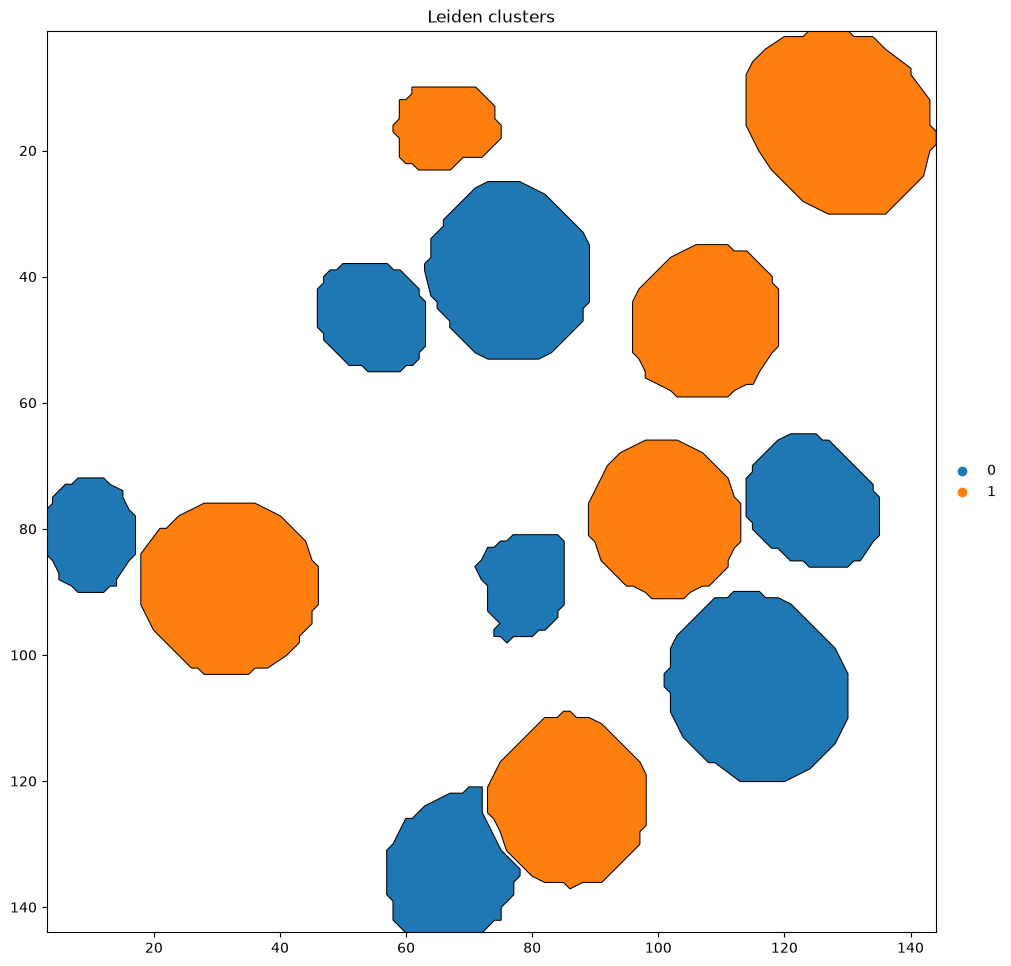

In [61]:
sdata.pl.render_shapes(
    "cell_boundaries",
    color="leiden",
    outline_alpha=1
).pl.show(
    title="Leiden clusters",
    coordinate_systems="global",
    figsize=(10, 10)
)
